# Đồ án Khoa học dữ liệu: Dự đoán giá bán nhà riêng tại TP.HCM

**Đề tài:** Xây dựng và so sánh các mô hình học máy trong dự đoán giá bán nhà riêng tại Thành phố Hồ Chí Minh dựa trên vị trí và các đặc điểm của bất động sản.

Notebook này xây dựng một quy trình có thể chạy lại từ dữ liệu thô đến kết quả cuối cùng:

1. Kiểm tra chất lượng và xác định phạm vi dữ liệu.
2. Làm sạch target, feature và tọa độ bằng các quy tắc được công bố rõ.
3. Nhận diện repost/duplicate theo nhiều tín hiệu, không chỉ dùng `Listing ID`.
4. Chia train/test sau khi gom nhóm để hạn chế leakage.
5. So sánh baseline, Ridge, Random Forest và gradient boosting.
6. Đo vai trò của vị trí bằng ablation study.
7. Giải thích mô hình và phân tích nhóm dự đoán sai.

**Câu hỏi nghiên cứu**

- RQ1: Mô hình nào dự đoán giá rao bán nhà riêng tốt nhất trên cùng một tập kiểm tra?
- RQ2: Thông tin vị trí cải thiện sai số dự đoán bao nhiêu so với chỉ dùng đặc điểm căn nhà?
- RQ3: Những biến nào ảnh hưởng nhiều nhất đến chất lượng dự đoán?
- RQ4: Mô hình thường sai ở phân khúc hoặc nhóm dữ liệu nào?

> Lưu ý: `Price` được xử lý như **giá rao toàn căn, đơn vị triệu đồng**, dựa trên đối chiếu giá trị số với tiêu đề tin. Cần bổ sung nguồn thu thập và license của dataset vào báo cáo chính thức nếu thông tin này nằm ngoài file CSV.


In [1]:
from pathlib import Path
from collections import defaultdict
import hashlib
import json
import math
import platform
import re
import sys
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd()
if not (ROOT / "data_public.csv").exists() and (ROOT.parent / "data_public.csv").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data_public.csv"
OUTPUT_DIR = ROOT / "outputs_notebook"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Data:", DATA_PATH)


Python: 3.14.4
Platform: Windows-11-10.0.26200-SP0
Data: D:\bài làm nháp đồ án KHDL\data_public.csv


## 1. Đọc dữ liệu và xác định đối tượng nghiên cứu

Đơn vị quan sát ban đầu là **tin đăng**. Đối tượng cần dự đoán là **nhà riêng**, vì vậy các loại bất động sản khác được loại trước mọi thống kê phục vụ mô hình.


In [2]:
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dữ liệu gốc: {raw.shape[0]:,} dòng x {raw.shape[1]} cột")
display(pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_n": raw.isna().sum(),
    "missing_pct": raw.isna().mean().mul(100).round(1),
    "unique_n": raw.nunique(dropna=True),
}))

property_counts = (
    raw["Property Type"].fillna("Thiếu")
    .value_counts()
    .rename_axis("property_type")
    .reset_index(name="rows")
)
display(property_counts)

house_raw = raw.loc[
    raw["Property Type"].astype("string").str.strip().eq("Nhà riêng")
].copy()
print(f"Sau khi lọc Nhà riêng: {len(house_raw):,} dòng")


Dữ liệu gốc: 51,304 dòng x 28 cột


,dtype,missing_n,missing_pct,unique_n
Title,object,0,0.000,48327
Price,float64,0,0.000,2674
Area,float64,104,0.200,7763
Location,object,0,0.000,5491
Listing ID,float64,0,0.000,51304
Last Updated,object,0,0.000,62
Property Type,object,0,0.000,7
Width,float64,17006,33.100,895
Length,float64,26037,50.800,882
Bedrooms,float64,34662,67.600,62


,property_type,rows
0,Đất,29530
1,Căn hộ chung cư,11012
2,Nhà riêng,8184
3,"Kho, nhà xưởng",1800
4,Nhà trọ,538
5,Khách sạn,196
6,Văn phòng,44


Sau khi lọc Nhà riêng: 8,184 dòng


## 2. Audit chất lượng dữ liệu

Phần này đo coverage của target và feature lõi, kiểm tra duplicate, khoảng thời gian, tọa độ và sự khác biệt giữa hai chế độ ghi địa giới. Bounding box tọa độ được dùng ở đây chỉ để loại lỗi hiển nhiên, không khẳng định một điểm chắc chắn thuộc ranh giới hành chính.


In [3]:
core_columns = [
    "Price", "Area", "Floors", "Bedrooms", "Bathrooms", "Width",
    "Length", "Position", "Alley Width", "Location", "Latitude",
    "Longitude", "Listing ID", "Title", "Description", "Last Updated Date",
]
quality = pd.DataFrame({
    "column": core_columns,
    "non_missing_n": [house_raw[c].notna().sum() for c in core_columns],
    "coverage_pct": [house_raw[c].notna().mean() * 100 for c in core_columns],
    "unique_n": [house_raw[c].nunique(dropna=True) for c in core_columns],
}).sort_values("coverage_pct", ascending=False)
display(quality.style.format({"coverage_pct": "{:.1f}%"}))

lat0 = pd.to_numeric(house_raw["Latitude"], errors="coerce")
lon0 = pd.to_numeric(house_raw["Longitude"], errors="coerce")
plausible_coord0 = lat0.between(10.30, 11.20) & lon0.between(106.20, 107.20)
new_boundary0 = house_raw["Location"].fillna("").str.contains(r"\(Mới\)", regex=True)
updated0 = pd.to_datetime(house_raw["Last Updated Date"], dayfirst=True, errors="coerce")
scraped0 = pd.to_datetime(house_raw["Scraped At"], errors="coerce")

audit_summary = pd.Series({
    "Nhà riêng thô": len(house_raw),
    "Dòng trùng hoàn toàn": int(house_raw.duplicated().sum()),
    "Listing ID bị lặp": int(house_raw["Listing ID"].duplicated().sum()),
    "Tọa độ không thiếu": int((lat0.notna() & lon0.notna()).sum()),
    "Tọa độ trong bounding box kiểm tra": int(plausible_coord0.sum()),
    "Địa giới có nhãn (Mới)": int(new_boundary0.sum()),
    "Địa giới không có nhãn (Mới)": int((~new_boundary0).sum()),
    "Ngày cập nhật nhỏ nhất": updated0.min(),
    "Ngày cập nhật lớn nhất": updated0.max(),
    "Thời điểm scrape nhỏ nhất": scraped0.min(),
    "Thời điểm scrape lớn nhất": scraped0.max(),
}, name="value")
display(audit_summary.to_frame())

coord_regime = pd.crosstab(
    np.where(new_boundary0, "TP.HCM (Mới)", "Cách ghi cũ"),
    np.where(plausible_coord0, "Có tọa độ hợp lệ", "Thiếu/không hợp lệ"),
    margins=True,
)
display(coord_regime)
print("Kết luận audit: missing tọa độ phụ thuộc mạnh vào chế độ ghi địa giới, nên không thể coi là missing ngẫu nhiên.")


,column,non_missing_n,coverage_pct,unique_n
0,Price,8184,100.0%,818
1,Area,8184,100.0%,1439
15,Last Updated Date,8184,100.0%,113
9,Location,8184,100.0%,2265
12,Listing ID,8184,100.0%,8184
13,Title,8184,100.0%,7800
14,Description,7582,92.6%,7112
5,Width,7494,91.6%,274
2,Floors,6076,74.2%,26
3,Bedrooms,5995,73.3%,49


,value
Nhà riêng thô,8184
Dòng trùng hoàn toàn,0
Listing ID bị lặp,0
Tọa độ không thiếu,5137
Tọa độ trong bounding box kiểm tra,5058
Địa giới có nhãn (Mới),5129
Địa giới không có nhãn (Mới),3055
Ngày cập nhật nhỏ nhất,2025-08-31 18:29:00
Ngày cập nhật lớn nhất,2025-09-30 18:37:00
Thời điểm scrape nhỏ nhất,2025-09-30 18:24:18


col_0,Có tọa độ hợp lệ,Thiếu/không hợp lệ,All
row_0,,,
Cách ghi cũ,0,3055,3055
TP.HCM (Mới),5058,71,5129
All,5058,3126,8184


Kết luận audit: missing tọa độ phụ thuộc mạnh vào chế độ ghi địa giới, nên không thể coi là missing ngẫu nhiên.


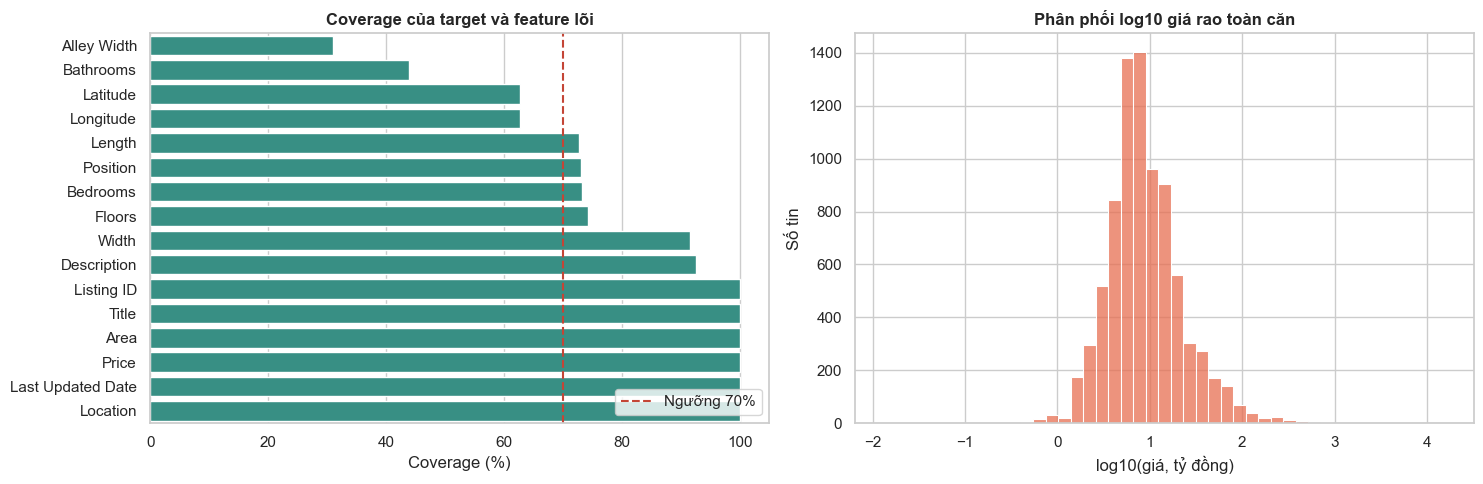

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

qplot = quality.sort_values("coverage_pct")
sns.barplot(data=qplot, x="coverage_pct", y="column", color="#2A9D8F", ax=axes[0])
axes[0].axvline(70, color="#C44536", linestyle="--", linewidth=1.5, label="Ngưỡng 70%")
axes[0].set(title="Coverage của target và feature lõi", xlabel="Coverage (%)", ylabel="")
axes[0].legend(loc="lower right")

price0 = pd.to_numeric(house_raw["Price"], errors="coerce") / 1000
sns.histplot(np.log10(price0[price0 > 0]), bins=45, color="#E76F51", ax=axes[1])
axes[1].set(
    title="Phân phối log10 giá rao toàn căn",
    xlabel="log10(giá, tỷ đồng)",
    ylabel="Số tin",
)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_data_quality.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Làm sạch dữ liệu và xây dựng nhóm căn nhà

Quy trình làm sạch được tách thành các quyết định có thể kiểm tra lại:

1. **Chuẩn hóa schema:** đổi tên cột, ép kiểu số/ngày, gom khoảng trắng và đổi chuỗi rỗng thành missing.
2. **Loại bản ghi không dùng được:** duplicate hoàn toàn, `Listing ID` lặp, target/diện tích thiếu hoặc vượt miền hợp lý và đơn giá ngầm định bất thường.
3. **Giữ dòng nhưng làm sạch feature tùy chọn:** chiều ngang/dài, phòng, tầng và độ rộng hẻm ngoài miền hợp lý được chuyển thành missing.
4. **Kiểm tra tọa độ:** cặp lat/lon ngoài bounding box rộng của TP.HCM mở rộng được chuyển thành missing; không tự geocode.
5. **Kiểm tra nhất quán:** so sánh diện tích với `width × length`, nhưng chỉ gắn cờ vì hai đại lượng có thể khác nhau về định nghĩa.
6. **Grouping repost:** kết hợp mô tả, tiêu đề, tọa độ, cấu trúc và môi giới; sau đó giữ tin cập nhật gần nhất và đầy đủ nhất trong mỗi nhóm.

Missing ở feature **không được điền bằng toàn bộ dataset tại bước này**. Median/mode và target encoding được fit bên trong từng train fold ở phần modeling để tránh leakage.


In [5]:
RENAME = {
    "Title": "title",
    "Price": "price_million",
    "Area": "area",
    "Location": "location",
    "Listing ID": "listing_id",
    "Last Updated": "last_updated_text",
    "Property Type": "property_type",
    "Width": "width",
    "Length": "length",
    "Bedrooms": "bedrooms",
    "Bathrooms": "bathrooms",
    "Floors": "floors",
    "Position": "position",
    "Direction": "direction",
    "Alley Width": "alley_width",
    "Road Type": "road_type",
    "Description": "description",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Agent Name": "agent_name",
    "Agent Listing Count": "agent_listing_count",
    "Province": "province",
    "Scraped At": "scraped_at",
    "Last Updated Date": "last_updated_date",
}

def normalize_text(value):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii").lower()
    return re.sub(r"[^a-z0-9]+", " ", text).strip()

def first_admin_part(location, prefixes):
    parts = [p.strip() for p in str(location).split(",") if p.strip()]
    for part in parts:
        normalized = normalize_text(part)
        if any(normalized.startswith(prefix) for prefix in prefixes):
            return part
    return np.nan

def rounded_token(value, step=1.0):
    if pd.isna(value):
        return "na"
    return str(int(round(float(value) / step)))

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1

def assign_property_groups(frame):
    work = frame.reset_index(drop=True).copy()
    uf = UnionFind(len(work))
    token_owner = {}

    for i, row in work.iterrows():
        title = normalize_text(row.get("title"))
        desc = normalize_text(row.get("description"))
        loc = normalize_text(row.get("location"))
        agent = normalize_text(row.get("agent_name"))
        area = rounded_token(row.get("area"), 1.0)
        price = rounded_token(row.get("price_million"), 100.0)
        width = rounded_token(row.get("width"), 0.5)
        floors = rounded_token(row.get("floors"), 1.0)
        beds = rounded_token(row.get("bedrooms"), 1.0)
        tokens = []

        if len(desc) >= 100:
            tokens.append("desc|" + desc + "|" + area + "|" + price)
        if len(title) >= 20 and loc:
            tokens.append("title|" + title + "|" + loc + "|" + area + "|" + price)
        if pd.notna(row.get("latitude")) and pd.notna(row.get("longitude")):
            coord = f"{row['latitude']:.4f}|{row['longitude']:.4f}"
            tokens.append("coord|" + coord + "|" + area + "|" + width + "|" + floors)
        if agent and loc:
            tokens.append(
                "agent|" + agent + "|" + loc + "|" + area + "|" + width
                + "|" + floors + "|" + beds + "|" + price
            )

        for token in tokens:
            digest = hashlib.sha1(token.encode("utf-8")).hexdigest()
            if digest in token_owner:
                uf.union(i, token_owner[digest])
            else:
                token_owner[digest] = i

    roots = [uf.find(i) for i in range(len(work))]
    root_to_group = {root: gid for gid, root in enumerate(dict.fromkeys(roots))}
    work["property_group_id"] = [root_to_group[root] for root in roots]
    return work


In [6]:
house = house_raw.rename(columns=RENAME).copy()
raw_house_rows = len(house)

# 1) Chuẩn hóa chuỗi: giữ tiếng Việt, chỉ gom khoảng trắng và đổi chuỗi rỗng thành missing.
text_columns = [
    "title", "location", "property_type", "position", "direction", "road_type",
    "description", "agent_name", "province",
]
blank_strings_replaced = {}
for col in text_columns:
    if col not in house.columns:
        continue
    series = house[col].astype("string")
    blank_mask = series.notna() & series.str.strip().eq("")
    blank_strings_replaced[col] = int(blank_mask.sum())
    normalized = (
        series.str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
    )
    normalized = normalized.astype(object)
    normalized[pd.isna(normalized)] = np.nan
    house[col] = normalized

# 2) Ép kiểu có theo dõi lỗi chuyển đổi.
numeric_cols = [
    "price_million", "area", "width", "length", "bedrooms", "bathrooms",
    "floors", "alley_width", "latitude", "longitude", "agent_listing_count",
]
numeric_conversion_failures = {}
for col in numeric_cols:
    before_non_missing = house[col].notna()
    converted = pd.to_numeric(house[col], errors="coerce")
    numeric_conversion_failures[col] = int((before_non_missing & converted.isna()).sum())
    house[col] = converted

house["last_updated_date"] = pd.to_datetime(
    house["last_updated_date"], dayfirst=True, errors="coerce"
)
house["scraped_at"] = pd.to_datetime(house["scraped_at"], errors="coerce")

# 3) Loại duplicate hoàn toàn và Listing ID lặp, ưu tiên bản ghi cập nhật mới hơn.
exact_duplicate_mask = house.duplicated(keep="first")
exact_duplicates_removed = int(exact_duplicate_mask.sum())
house = house.loc[~exact_duplicate_mask].copy()

house = house.sort_values("last_updated_date", ascending=False, na_position="last")
listing_duplicate_mask = house["listing_id"].notna() & house["listing_id"].duplicated(keep="first")
listing_duplicates_removed = int(listing_duplicate_mask.sum())
house = house.loc[~listing_duplicate_mask].copy()

# 4) Cờ chất lượng cho target và diện tích. Price có đơn vị triệu đồng.
price_ok = house["price_million"].between(500, 500_000)
area_ok = house["area"].between(10, 1_000)
house["implied_price_m2_million"] = house["price_million"] / house["area"]
unit_ok = house["implied_price_m2_million"].between(3, 1_500)

house["flag_invalid_price"] = ~price_ok
house["flag_invalid_area"] = ~area_ok
house["flag_invalid_implied_unit"] = ~unit_ok
required_ok = price_ok & area_ok & unit_ok

rows_after_exact = raw_house_rows - exact_duplicates_removed
rows_after_listing = rows_after_exact - listing_duplicates_removed
cleaning_log = pd.DataFrame([
    {"step": "Nhà riêng thô", "rows_removed": 0, "rows_remaining": raw_house_rows},
    {"step": "Loại duplicate hoàn toàn", "rows_removed": exact_duplicates_removed, "rows_remaining": rows_after_exact},
    {"step": "Loại Listing ID lặp", "rows_removed": listing_duplicates_removed, "rows_remaining": rows_after_listing},
    {
        "step": "Loại target/diện tích/đơn giá ngầm định không hợp lệ",
        "rows_removed": int((~required_ok).sum()),
        "rows_remaining": int(required_ok.sum()),
    },
])
house = house.loc[required_ok].copy()

# 5) Feature tùy chọn ngoài miền hợp lý được chuyển thành missing, không loại cả dòng.
valid_ranges = {
    "width": (1.5, 50),
    "length": (2, 200),
    "bedrooms": (1, 50),
    "bathrooms": (1, 50),
    "floors": (1, 30),
    "alley_width": (0.5, 100),
}
optional_invalid = {}
optional_invalid_any = pd.Series(False, index=house.index)
for col, (lower, upper) in valid_ranges.items():
    invalid = house[col].notna() & ~house[col].between(lower, upper)
    optional_invalid[col] = int(invalid.sum())
    optional_invalid_any |= invalid
    house.loc[invalid, col] = np.nan

# 6) Tọa độ: cặp thiếu một phần hoặc ngoài bounding box đều được chuyển thành missing.
coord_any_present = house[["latitude", "longitude"]].notna().any(axis=1)
coord_complete = house[["latitude", "longitude"]].notna().all(axis=1)
coord_ok = (
    coord_complete
    & house["latitude"].between(10.30, 11.20)
    & house["longitude"].between(106.20, 107.20)
)
invalid_coordinate_rows = int((coord_any_present & ~coord_ok).sum())
house.loc[~coord_ok, ["latitude", "longitude"]] = np.nan

# 7) Kiểm tra width × length so với Area; chỉ gắn cờ, không loại dữ liệu.
house["dimension_product_m2"] = house["width"] * house["length"]
house["area_to_dimension_ratio"] = house["area"] / house["dimension_product_m2"]
house["flag_dimension_mismatch"] = (
    house["area_to_dimension_ratio"].notna()
    & ~house["area_to_dimension_ratio"].between(0.55, 1.80)
)

house["ward"] = house["location"].map(
    lambda x: first_admin_part(x, ("phuong", "xa", "thi tran"))
)
house["district"] = house["location"].map(
    lambda x: first_admin_part(x, ("quan", "huyen", "thanh pho thu duc"))
)
house["location_regime"] = np.where(
    house["location"].fillna("").str.contains(r"\(Mới\)", regex=True),
    "new_boundary_label",
    "old_boundary_label",
)

# 8) Group repost/duplicate tiềm năng và chọn một bản ghi đại diện cho mỗi căn.
house = assign_property_groups(house)
group_sizes = house.groupby("property_group_id").size()
rows_in_multi_groups = int(group_sizes[group_sizes > 1].sum())
groups_with_reposts = int((group_sizes > 1).sum())

completeness_cols = [
    "area", "width", "length", "bedrooms", "bathrooms", "floors",
    "position", "alley_width", "ward", "district", "latitude", "longitude",
]
house["completeness_score"] = house[completeness_cols].notna().sum(axis=1)
house = house.sort_values(
    ["property_group_id", "last_updated_date", "completeness_score"],
    ascending=[True, False, False],
)
modeling = house.drop_duplicates("property_group_id", keep="first").copy()

cleaning_log = pd.concat([
    cleaning_log,
    pd.DataFrame([
        {
            "step": "Gom repost và giữ một bản ghi đại diện",
            "rows_removed": len(house) - len(modeling),
            "rows_remaining": len(modeling),
        }
    ]),
], ignore_index=True)

cleaning_diagnostics = pd.DataFrame([
    ("Chuỗi rỗng chuyển thành missing", sum(blank_strings_replaced.values())),
    ("Lỗi ép kiểu số", sum(numeric_conversion_failures.values())),
    ("Dòng có feature tùy chọn ngoài miền", int(optional_invalid_any.sum())),
    ("Dòng tọa độ có giá trị nhưng không hợp lệ", invalid_coordinate_rows),
    ("Dòng width × length không nhất quán với Area", int(house["flag_dimension_mismatch"].sum())),
    ("Nhóm có từ hai tin trở lên", groups_with_reposts),
    ("Dòng thuộc nhóm có từ hai tin trở lên", rows_in_multi_groups),
], columns=["diagnostic", "count"])

display(Markdown("**Cleaning funnel**"))
display(cleaning_log)
display(Markdown("**Các giá trị được sửa hoặc gắn cờ nhưng không làm mất cả dòng**"))
display(cleaning_diagnostics)
display(pd.Series(optional_invalid, name="values_set_to_missing").to_frame())
display(group_sizes.describe().rename("group_size").to_frame())
print(f"Ước tính còn {len(modeling):,} căn độc lập từ {len(house):,} dòng hợp lệ.")


**Cleaning funnel**

,step,rows_removed,rows_remaining
0,Nhà riêng thô,0,8184
1,Loại duplicate hoàn toàn,0,8184
2,Loại Listing ID lặp,0,8184
3,Loại target/diện tích/đơn giá ngầm định không ...,193,7991
4,Gom repost và giữ một bản ghi đại diện,509,7482


**Các giá trị được sửa hoặc gắn cờ nhưng không làm mất cả dòng**

,diagnostic,count
0,Chuỗi rỗng chuyển thành missing,0
1,Lỗi ép kiểu số,0
2,Dòng có feature tùy chọn ngoài miền,78
3,Dòng tọa độ có giá trị nhưng không hợp lệ,54
4,Dòng width × length không nhất quán với Area,128
5,Nhóm có từ hai tin trở lên,262
6,Dòng thuộc nhóm có từ hai tin trở lên,771


,values_set_to_missing
width,11
length,11
bedrooms,8
bathrooms,2
floors,44
alley_width,6


,group_size
count,"7,482.000"
mean,1.068
std,0.734
min,1.000
25%,1.000
50%,1.000
75%,1.000
max,46.000


Ước tính còn 7,482 căn độc lập từ 7,991 dòng hợp lệ.


,feature,coverage_before_pct,coverage_after_pct,coverage_change_pp
0,Price,100.0%,100.0%,+0.0
1,Area,100.0%,100.0%,+0.0
2,Floors,74.2%,75.0%,+0.8
3,Bedrooms,73.3%,74.7%,+1.4
4,Bathrooms,44.0%,45.6%,+1.7
5,Width,91.6%,91.9%,+0.3
6,Length,72.8%,74.2%,+1.3
7,Position,73.1%,74.5%,+1.4
8,Alley Width,30.9%,30.5%,-0.5
9,Location,100.0%,100.0%,+0.0


**Mức độ tái sử dụng tọa độ sau cleaning**

,value
rows_with_valid_coordinates,4566
unique_coordinate_pairs_5dp,4337
rows_in_reused_coordinate_pairs,270
maximum_rows_sharing_one_pair,76


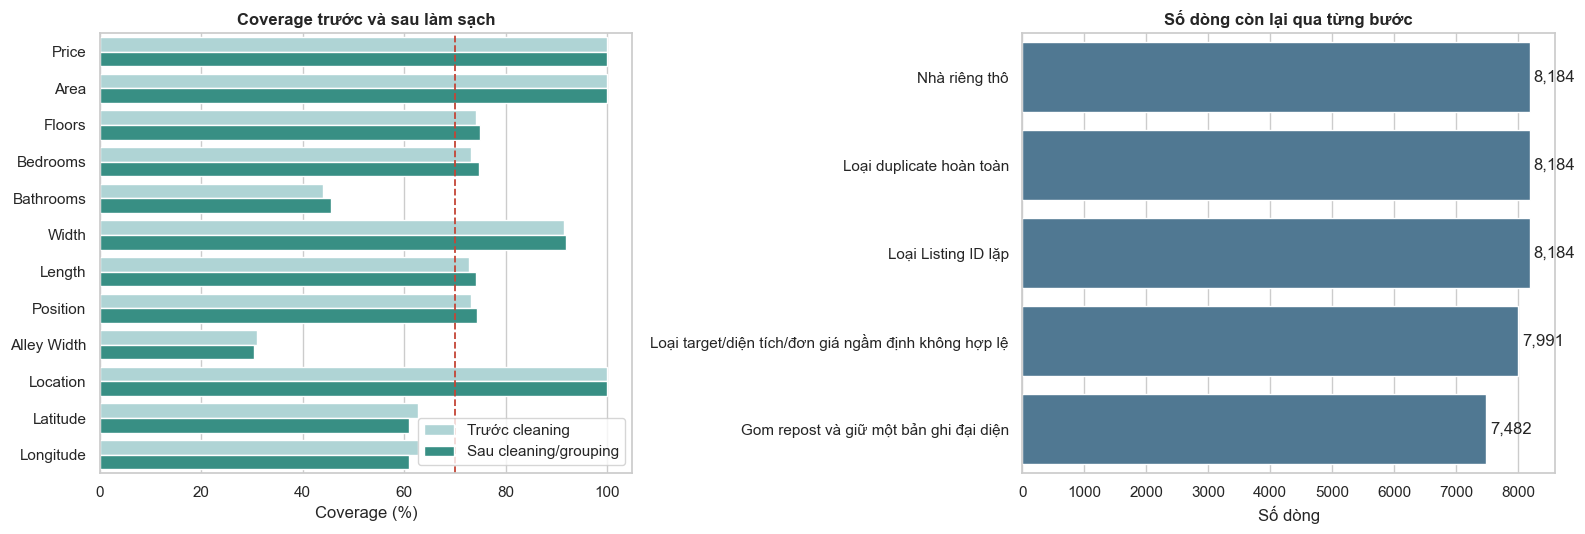

In [7]:
# So sánh coverage trước và sau cleaning/grouping.
coverage_map = {
    "Price": "price_million",
    "Area": "area",
    "Floors": "floors",
    "Bedrooms": "bedrooms",
    "Bathrooms": "bathrooms",
    "Width": "width",
    "Length": "length",
    "Position": "position",
    "Alley Width": "alley_width",
    "Location": "location",
    "Latitude": "latitude",
    "Longitude": "longitude",
}
missingness_before_after = pd.DataFrame([
    {
        "feature": raw_col,
        "coverage_before_pct": house_raw[raw_col].notna().mean() * 100,
        "coverage_after_pct": modeling[clean_col].notna().mean() * 100,
    }
    for raw_col, clean_col in coverage_map.items()
])
missingness_before_after["coverage_change_pp"] = (
    missingness_before_after["coverage_after_pct"]
    - missingness_before_after["coverage_before_pct"]
)

valid_coord_rows = modeling.dropna(subset=["latitude", "longitude"]).copy()
coordinate_reuse = (
    valid_coord_rows.assign(
        coordinate_pair=valid_coord_rows["latitude"].round(5).astype(str)
        + ","
        + valid_coord_rows["longitude"].round(5).astype(str)
    )
    .groupby("coordinate_pair", as_index=False)
    .size()
    .sort_values("size", ascending=False)
)
coordinate_reuse_summary = pd.Series({
    "rows_with_valid_coordinates": len(valid_coord_rows),
    "unique_coordinate_pairs_5dp": coordinate_reuse["coordinate_pair"].nunique(),
    "rows_in_reused_coordinate_pairs": int(
        coordinate_reuse.loc[coordinate_reuse["size"] > 1, "size"].sum()
    ),
    "maximum_rows_sharing_one_pair": int(coordinate_reuse["size"].max()),
})

display(missingness_before_after.style.format({
    "coverage_before_pct": "{:.1f}%",
    "coverage_after_pct": "{:.1f}%",
    "coverage_change_pp": "{:+.1f}",
}))
display(Markdown("**Mức độ tái sử dụng tọa độ sau cleaning**"))
display(coordinate_reuse_summary.to_frame("value"))

coverage_long = missingness_before_after.melt(
    id_vars="feature",
    value_vars=["coverage_before_pct", "coverage_after_pct"],
    var_name="stage",
    value_name="coverage_pct",
)
coverage_long["stage"] = coverage_long["stage"].map({
    "coverage_before_pct": "Trước cleaning",
    "coverage_after_pct": "Sau cleaning/grouping",
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.barplot(
    data=coverage_long,
    x="coverage_pct",
    y="feature",
    hue="stage",
    palette=["#A8DADC", "#2A9D8F"],
    ax=axes[0],
)
axes[0].axvline(70, color="#C44536", linestyle="--", linewidth=1.3)
axes[0].set(title="Coverage trước và sau làm sạch", xlabel="Coverage (%)", ylabel="")
axes[0].legend(title="")

funnel_plot = cleaning_log.copy()
sns.barplot(data=funnel_plot, x="rows_remaining", y="step", color="#457B9D", ax=axes[1])
axes[1].set(title="Số dòng còn lại qua từng bước", xlabel="Số dòng", ylabel="")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="{:,.0f}", padding=3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / "01b_cleaning_impact.png", dpi=160, bbox_inches="tight")
plt.show()


## 4. Feature engineering

Không sử dụng `title`, `description`, `Listing ID`, thông tin môi giới hoặc đơn giá/m² làm feature. Tiêu đề và mô tả thường chứa trực tiếp giá rao; đơn giá/m² được tính từ target; các biến này sẽ gây leakage.

Tọa độ được dùng cùng một cờ `coordinate_missing` vì tỷ lệ thiếu có cấu trúc. Khoảng cách đến chợ Bến Thành chỉ là một feature không gian đơn giản, không mang ý nghĩa nhân quả.


In [8]:
def haversine_km(lat1, lon1, lat2=10.7725, lon2=106.6980):
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)
    dlat = lat1 - lat2
    dlon = lon1 - lon2
    a = np.sin(dlat / 2) ** 2 + np.cos(lat2) * np.cos(lat1) * np.sin(dlon / 2) ** 2
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))

modeling["coordinate_missing"] = modeling["latitude"].isna().astype(int)
modeling["distance_to_center_km"] = haversine_km(
    modeling["latitude"], modeling["longitude"]
)
modeling["total_rooms_known"] = modeling[["bedrooms", "bathrooms"]].sum(
    axis=1, min_count=1
)
modeling["lot_shape_ratio"] = modeling["width"] / modeling["length"]
modeling["footprint_from_dimensions"] = modeling["width"] * modeling["length"]

structural_numeric = [
    "area", "width", "length", "bedrooms", "bathrooms", "floors",
    "alley_width", "total_rooms_known", "lot_shape_ratio",
    "footprint_from_dimensions",
]
structural_categorical = ["position", "direction", "road_type"]
administrative_categorical = ["ward", "district", "location_regime"]
coordinate_numeric = [
    "latitude", "longitude", "distance_to_center_km", "coordinate_missing"
]

FEATURE_SETS = {
    "Chỉ đặc điểm căn nhà": structural_numeric + structural_categorical,
    "Thêm địa giới thô": structural_numeric + structural_categorical + administrative_categorical,
    "Thêm tọa độ": structural_numeric + structural_categorical + coordinate_numeric,
    "Đầy đủ vị trí": (
        structural_numeric + structural_categorical
        + administrative_categorical + coordinate_numeric
    ),
}
FULL_FEATURES = FEATURE_SETS["Đầy đủ vị trí"]
TARGET = "price_million"

feature_dictionary = pd.DataFrame([
    ("price_million", "Target", "Giá rao toàn căn, triệu đồng"),
    ("area", "Numeric", "Diện tích, m²"),
    ("width / length", "Numeric", "Kích thước lô nhà, m"),
    ("bedrooms / bathrooms / floors", "Numeric", "Đặc điểm công năng"),
    ("position / road_type / alley_width", "Mixed", "Mặt tiền, hẻm và đường tiếp cận"),
    ("ward / district", "Categorical", "Địa giới lấy trực tiếp từ Location"),
    ("latitude / longitude", "Numeric", "Tọa độ hợp lệ trong bounding box kiểm tra"),
    ("distance_to_center_km", "Derived", "Khoảng cách Haversine đến chợ Bến Thành"),
    ("coordinate_missing", "Binary", "Cờ thiếu tọa độ có cấu trúc"),
], columns=["feature", "type", "meaning"])
display(feature_dictionary)


,feature,type,meaning
0,price_million,Target,"Giá rao toàn căn, triệu đồng"
1,area,Numeric,"Diện tích, m²"
2,width / length,Numeric,"Kích thước lô nhà, m"
3,bedrooms / bathrooms / floors,Numeric,Đặc điểm công năng
4,position / road_type / alley_width,Mixed,"Mặt tiền, hẻm và đường tiếp cận"
5,ward / district,Categorical,Địa giới lấy trực tiếp từ Location
6,latitude / longitude,Numeric,Tọa độ hợp lệ trong bounding box kiểm tra
7,distance_to_center_km,Derived,Khoảng cách Haversine đến chợ Bến Thành
8,coordinate_missing,Binary,Cờ thiếu tọa độ có cấu trúc


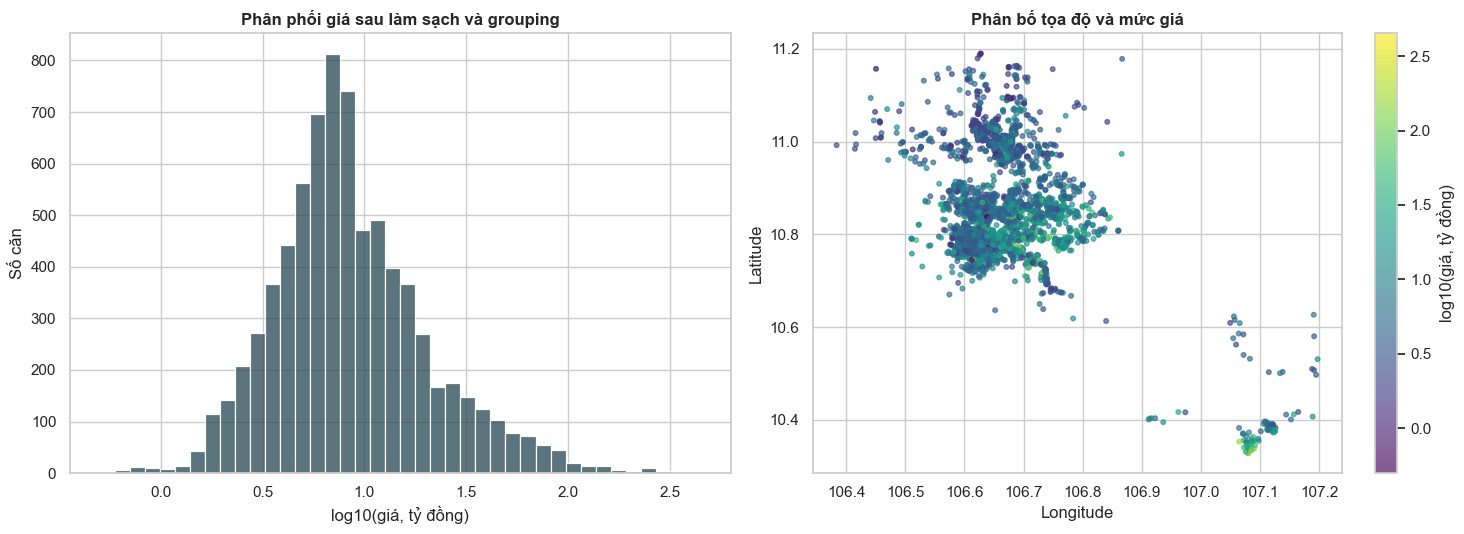

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(
    data=modeling,
    x=np.log10(modeling["price_million"] / 1000),
    bins=40,
    color="#264653",
    ax=axes[0],
)
axes[0].set(
    title="Phân phối giá sau làm sạch và grouping",
    xlabel="log10(giá, tỷ đồng)",
    ylabel="Số căn",
)

coord_plot = modeling.dropna(subset=["latitude", "longitude"])
scatter = axes[1].scatter(
    coord_plot["longitude"],
    coord_plot["latitude"],
    c=np.log10(coord_plot["price_million"] / 1000),
    cmap="viridis",
    s=11,
    alpha=0.65,
)
axes[1].set(
    title="Phân bố tọa độ và mức giá",
    xlabel="Longitude",
    ylabel="Latitude",
)
fig.colorbar(scatter, ax=axes[1], label="log10(giá, tỷ đồng)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "02_cleaned_eda.png", dpi=160, bbox_inches="tight")
plt.show()


## 5. Chia train/test chống leakage

Grouping và chọn bản ghi đại diện diễn ra **trước khi split**. Tập test chiếm 20% số căn và được phân tầng theo decile của log-giá. Test set chỉ được dùng để báo cáo cuối và các thí nghiệm ablation đã xác định trước.


In [10]:
y = modeling[TARGET].copy()
price_bins = pd.qcut(np.log1p(y), q=10, labels=False, duplicates="drop")
splitter = StratifiedShuffleSplit(
    n_splits=1, test_size=0.20, random_state=RANDOM_STATE
)
train_idx, test_idx = next(splitter.split(modeling, price_bins))

train_df = modeling.iloc[train_idx].copy()
test_df = modeling.iloc[test_idx].copy()
y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

assert set(train_df["property_group_id"]).isdisjoint(test_df["property_group_id"])
split_summary = pd.DataFrame({
    "split": ["Train", "Test"],
    "rows": [len(train_df), len(test_df)],
    "median_price_billion": [y_train.median() / 1000, y_test.median() / 1000],
    "coordinate_coverage_pct": [
        train_df["latitude"].notna().mean() * 100,
        test_df["latitude"].notna().mean() * 100,
    ],
    "new_boundary_pct": [
        train_df["location_regime"].eq("new_boundary_label").mean() * 100,
        test_df["location_regime"].eq("new_boundary_label").mean() * 100,
    ],
})
display(split_summary.style.format({
    "median_price_billion": "{:.2f}",
    "coordinate_coverage_pct": "{:.1f}%",
    "new_boundary_pct": "{:.1f}%",
}))


,split,rows,median_price_billion,coordinate_coverage_pct,new_boundary_pct
0,Train,5985,7.60,61.0%,61.6%
1,Test,1497,7.60,61.3%,61.8%


## 6. Tiền xử lý và mô hình

Tất cả imputer và encoder nằm trong `Pipeline`, nên chỉ học tham số từ train fold. Biến phân loại dùng one-hot cho Ridge và target encoding có cross-fitting cho mô hình cây. Target được biến đổi `log1p` khi huấn luyện; dự đoán được đổi về triệu/tỷ đồng trước khi tính metric.

Metric chính là MAE (tỷ đồng). RMSE nhạy với căn rất đắt, MedAE mô tả sai số điển hình, R² đo phần phương sai được giải thích, và `within_20pct` là tỷ lệ dự đoán nằm trong ±20% giá rao.


In [11]:
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

def split_feature_types(features):
    categorical_pool = set(structural_categorical + administrative_categorical)
    categorical = [c for c in features if c in categorical_pool]
    numeric = [c for c in features if c not in categorical_pool]
    return numeric, categorical

def build_preprocessor(features, categorical_mode="target", scale_numeric=False):
    numeric, categorical = split_feature_types(features)
    num_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(num_steps)

    if categorical_mode == "onehot":
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=5,
            )),
        ])
    else:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
            ("encoder", TargetEncoder(
                target_type="continuous",
                smooth="auto",
                cv=5,
                shuffle=True,
                random_state=RANDOM_STATE,
            )),
        ])

    return ColumnTransformer(
        [("num", num_pipe, numeric), ("cat", cat_pipe, categorical)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def make_model(name, features):
    if name == "Baseline median":
        return DummyRegressor(strategy="median")
    if name == "Ridge":
        return Pipeline([
            ("preprocess", build_preprocessor(
                features, categorical_mode="onehot", scale_numeric=True
            )),
            ("model", Ridge(alpha=10.0)),
        ])
    if name == "Random Forest":
        return Pipeline([
            ("preprocess", build_preprocessor(features, categorical_mode="target")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                max_features=0.80,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ])
    if name == "Gradient Boosting":
        if HAS_XGBOOST:
            estimator = XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=500,
                learning_rate=0.035,
                max_depth=4,
                min_child_weight=5,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.05,
                reg_lambda=5.0,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        else:
            estimator = HistGradientBoostingRegressor(
                learning_rate=0.05,
                max_iter=400,
                max_leaf_nodes=31,
                l2_regularization=3.0,
                random_state=RANDOM_STATE,
            )
        return Pipeline([
            ("preprocess", build_preprocessor(features, categorical_mode="target")),
            ("model", estimator),
        ])
    raise ValueError(f"Unknown model: {name}")

MODEL_NAMES = ["Baseline median", "Ridge", "Random Forest", "Gradient Boosting"]

def original_scale_predictions(model, X):
    return np.clip(np.expm1(model.predict(X)), 0, None)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_true - y_pred) / y_true
    return {
        "mae_billion": mean_absolute_error(y_true, y_pred) / 1000,
        "rmse_billion": np.sqrt(mean_squared_error(y_true, y_pred)) / 1000,
        "medae_billion": median_absolute_error(y_true, y_pred) / 1000,
        "r2": r2_score(y_true, y_pred),
        "mape_pct": ape.mean() * 100,
        "within_20pct": (ape <= 0.20).mean() * 100,
    }

print("Backend boosting:", "XGBoost" if HAS_XGBOOST else "HistGradientBoostingRegressor")


Backend boosting: XGBoost


## 7. Cross-validation trên train set

Ba fold được phân tầng theo log-giá. Hyperparameter được giữ cố định, không tối ưu theo test set. Mô hình thắng được chọn bằng MAE cross-validation trung bình.


In [12]:
train_bins = pd.qcut(np.log1p(y_train), q=10, labels=False, duplicates="drop")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for model_name in MODEL_NAMES:
    for fold, (fit_idx, valid_idx) in enumerate(cv.split(train_df, train_bins), start=1):
        model = make_model(model_name, FULL_FEATURES)
        X_fit = train_df.iloc[fit_idx][FULL_FEATURES]
        X_valid = train_df.iloc[valid_idx][FULL_FEATURES]
        y_fit = y_train.iloc[fit_idx]
        y_valid = y_train.iloc[valid_idx]

        model.fit(X_fit, np.log1p(y_fit))
        pred = original_scale_predictions(model, X_valid)
        row = {"model": model_name, "fold": fold}
        row.update(regression_metrics(y_valid, pred))
        cv_rows.append(row)
        print(f"{model_name:18s} fold {fold}: MAE = {row['mae_billion']:.3f} tỷ")

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results.groupby("model", as_index=False)
    .agg(
        cv_mae_billion=("mae_billion", "mean"),
        cv_mae_std=("mae_billion", "std"),
        cv_rmse_billion=("rmse_billion", "mean"),
        cv_medae_billion=("medae_billion", "mean"),
        cv_r2=("r2", "mean"),
        cv_within_20pct=("within_20pct", "mean"),
    )
    .sort_values("cv_mae_billion")
)
display(cv_summary.style.format({
    "cv_mae_billion": "{:.3f}",
    "cv_mae_std": "{:.3f}",
    "cv_rmse_billion": "{:.3f}",
    "cv_medae_billion": "{:.3f}",
    "cv_r2": "{:.3f}",
    "cv_within_20pct": "{:.1f}%",
}))


Baseline median    fold 1: MAE = 8.825 tỷ
Baseline median    fold 2: MAE = 8.659 tỷ
Baseline median    fold 3: MAE = 9.345 tỷ
Ridge              fold 1: MAE = 5.733 tỷ
Ridge              fold 2: MAE = 5.836 tỷ
Ridge              fold 3: MAE = 6.287 tỷ


Random Forest      fold 1: MAE = 4.867 tỷ


Random Forest      fold 2: MAE = 4.670 tỷ


Random Forest      fold 3: MAE = 5.283 tỷ


Gradient Boosting  fold 1: MAE = 4.830 tỷ


Gradient Boosting  fold 2: MAE = 4.423 tỷ


Gradient Boosting  fold 3: MAE = 5.150 tỷ


,model,cv_mae_billion,cv_mae_std,cv_rmse_billion,cv_medae_billion,cv_r2,cv_within_20pct
1,Gradient Boosting,4.801,0.364,14.313,1.531,0.579,49.3%
2,Random Forest,4.940,0.313,15.088,1.577,0.532,48.7%
3,Ridge,5.952,0.295,17.582,1.795,0.356,42.6%
0,Baseline median,8.943,0.358,22.873,3.600,-0.079,23.8%


## 8. Đánh giá cuối trên test set

Mỗi mô hình được fit lại bằng toàn bộ train set. Việc chọn mô hình tốt nhất dựa trên cross-validation, không dựa trên test MAE.


In [13]:
fitted_models = {}
test_rows = []
predictions_by_model = {}

for model_name in MODEL_NAMES:
    model = make_model(model_name, FULL_FEATURES)
    model.fit(train_df[FULL_FEATURES], np.log1p(y_train))
    pred = original_scale_predictions(model, test_df[FULL_FEATURES])
    fitted_models[model_name] = model
    predictions_by_model[model_name] = pred
    row = {"model": model_name}
    row.update(regression_metrics(y_test, pred))
    test_rows.append(row)

test_results = pd.DataFrame(test_rows)
comparison = (
    cv_summary.merge(test_results, on="model", how="left")
    .sort_values("cv_mae_billion")
    .reset_index(drop=True)
)
best_model_name = comparison.loc[
    comparison["model"].ne("Baseline median"), "model"
].iloc[0]
best_model = fitted_models[best_model_name]
best_pred = predictions_by_model[best_model_name]

display(comparison.style.format({
    c: "{:.3f}" for c in comparison.columns
    if c not in ["model", "cv_within_20pct", "within_20pct"]
}).format({
    "cv_within_20pct": "{:.1f}%",
    "within_20pct": "{:.1f}%",
}))
print(f"Mô hình được chọn theo CV: {best_model_name}")


,model,cv_mae_billion,cv_mae_std,cv_rmse_billion,cv_medae_billion,cv_r2,cv_within_20pct,mae_billion,rmse_billion,medae_billion,r2,mape_pct,within_20pct
0,Gradient Boosting,4.801044,0.364077,14.313143,1.531260,0.579303,49.3%,4.830894,15.877538,1.536066,0.629282,31.306091,50.6%
1,Random Forest,4.940032,0.312916,15.088189,1.577040,0.531805,48.7%,5.079274,17.049085,1.461895,0.572556,32.838328,49.7%
2,Ridge,5.951886,0.294813,17.582041,1.794785,0.355611,42.6%,6.388286,19.788225,1.843961,0.424174,40.596353,41.9%
3,Baseline median,8.943175,0.357813,22.872957,3.600000,-0.078791,23.8%,9.584355,26.945561,3.500000,-0.067706,67.509059,23.5%


Mô hình được chọn theo CV: Gradient Boosting


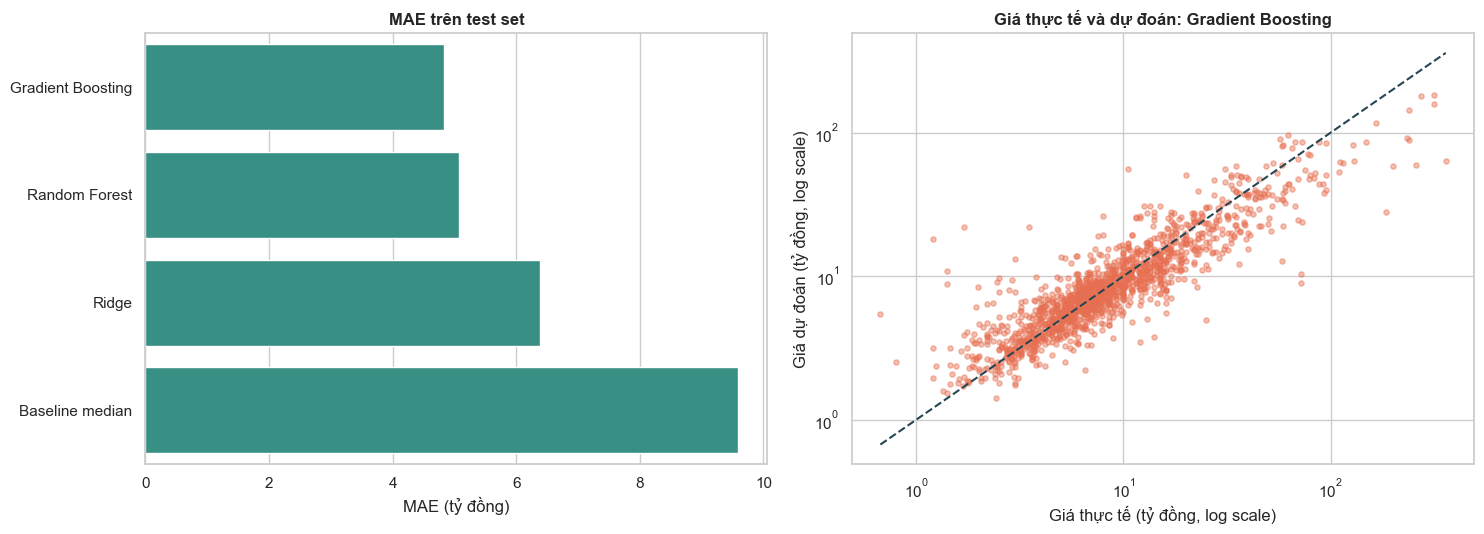

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

order = comparison.sort_values("mae_billion")["model"]
sns.barplot(
    data=comparison,
    x="mae_billion",
    y="model",
    order=order,
    color="#2A9D8F",
    ax=axes[0],
)
axes[0].set(title="MAE trên test set", xlabel="MAE (tỷ đồng)", ylabel="")

axes[1].scatter(y_test / 1000, best_pred / 1000, s=14, alpha=0.45, color="#E76F51")
lower = min((y_test / 1000).min(), (best_pred / 1000).min())
upper = max((y_test / 1000).max(), (best_pred / 1000).max())
axes[1].plot([lower, upper], [lower, upper], "--", color="#264653", linewidth=1.5)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(
    title=f"Giá thực tế và dự đoán: {best_model_name}",
    xlabel="Giá thực tế (tỷ đồng, log scale)",
    ylabel="Giá dự đoán (tỷ đồng, log scale)",
)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "03_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


## 9. Ablation study: vai trò của vị trí

Cùng một thuật toán thắng theo CV được huấn luyện lại với bốn tập feature đã định trước. Chênh lệch MAE so với mô hình chỉ dùng đặc điểm căn nhà cho biết giá trị dự báo bổ sung của từng dạng thông tin vị trí.


,feature_set,n_features_raw,mae_billion,rmse_billion,medae_billion,r2,mape_pct,within_20pct,mae_improvement_vs_structure_pct
3,Đầy đủ vị trí,20,4.831,15.878,1.536,0.629,31.3%,50.6%,31.1%
1,Thêm địa giới thô,16,5.176,16.225,1.729,0.613,35.2%,45.8%,26.1%
2,Thêm tọa độ,17,5.837,19.900,1.619,0.418,36.2%,46.0%,16.7%
0,Chỉ đặc điểm căn nhà,13,7.009,21.650,2.168,0.311,47.8%,35.7%,0.0%


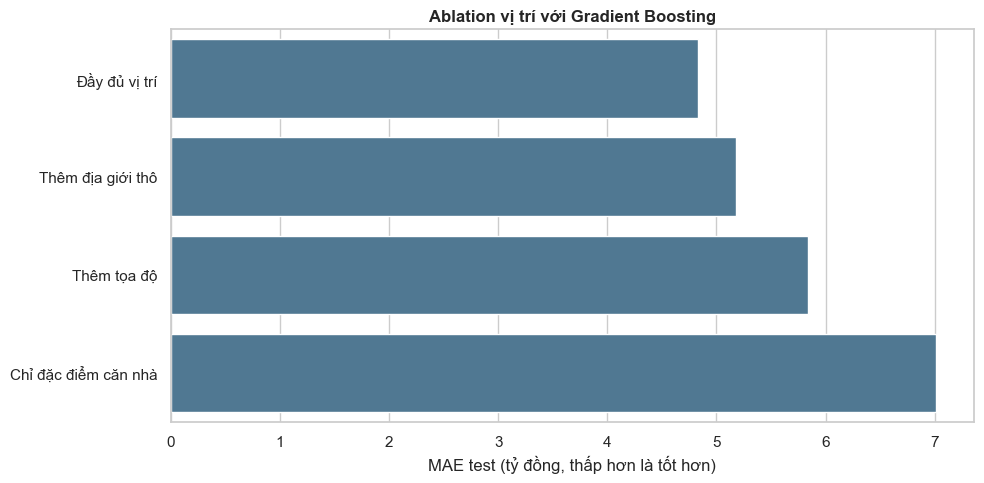

In [15]:
ablation_rows = []
ablation_models = {}
for feature_set_name, features in FEATURE_SETS.items():
    model = make_model(best_model_name, features)
    model.fit(train_df[features], np.log1p(y_train))
    pred = original_scale_predictions(model, test_df[features])
    row = {"feature_set": feature_set_name, "n_features_raw": len(features)}
    row.update(regression_metrics(y_test, pred))
    ablation_rows.append(row)
    ablation_models[feature_set_name] = model

ablation = pd.DataFrame(ablation_rows).sort_values("mae_billion")
base_mae = ablation.loc[
    ablation["feature_set"].eq("Chỉ đặc điểm căn nhà"), "mae_billion"
].iloc[0]
ablation["mae_improvement_vs_structure_pct"] = (
    (base_mae - ablation["mae_billion"]) / base_mae * 100
)
display(ablation.style.format({
    "mae_billion": "{:.3f}",
    "rmse_billion": "{:.3f}",
    "medae_billion": "{:.3f}",
    "r2": "{:.3f}",
    "mape_pct": "{:.1f}%",
    "within_20pct": "{:.1f}%",
    "mae_improvement_vs_structure_pct": "{:.1f}%",
}))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=ablation,
    x="mae_billion",
    y="feature_set",
    color="#457B9D",
)
plt.title(f"Ablation vị trí với {best_model_name}")
plt.xlabel("MAE test (tỷ đồng, thấp hơn là tốt hơn)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_location_ablation.png", dpi=160, bbox_inches="tight")
plt.show()


## 10. Explainability bằng permutation importance

Permutation importance đo mức MAE tăng lên khi xáo trộn từng feature gốc trên test set. Phương pháp này đọc được toàn bộ pipeline và phản ánh giá trị dự báo, nhưng không chứng minh quan hệ nhân quả.


,feature,importance_mae_million,importance_std_million,importance_mae_billion
0,area,3897.5,237.7,3.897
13,ward,1440.4,100.0,1.440
14,district,1062.7,48.9,1.063
18,distance_to_center_km,769.5,64.3,0.769
5,floors,547.2,50.3,0.547
16,latitude,350.9,102.6,0.351
1,width,317.6,37.2,0.318
10,position,195.3,41.3,0.195
6,alley_width,151.3,9.4,0.151
15,location_regime,128.2,4.4,0.128


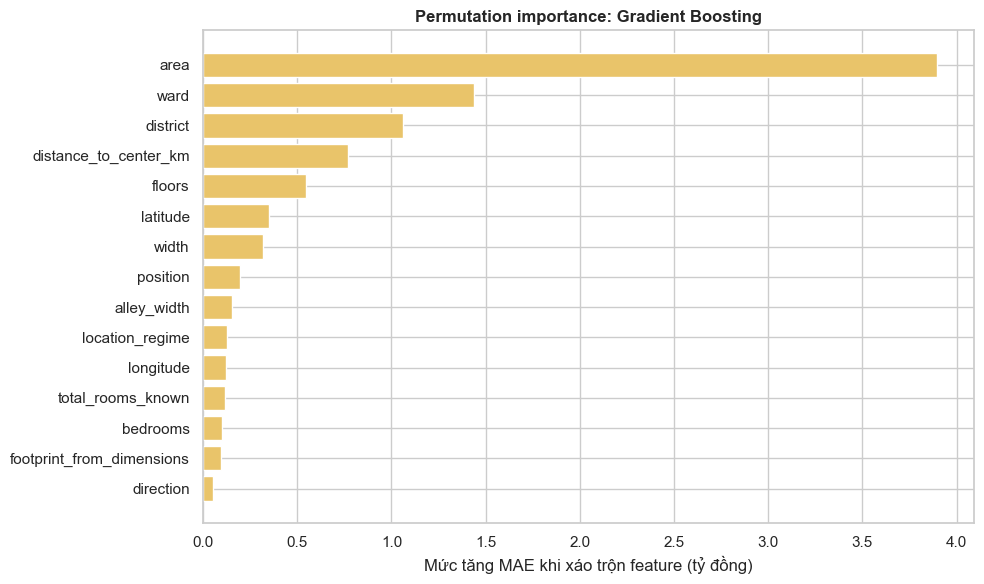

In [16]:
def negative_mae_original_scale(estimator, X, y_log):
    actual = np.expm1(np.asarray(y_log))
    predicted = original_scale_predictions(estimator, X)
    return -mean_absolute_error(actual, predicted)

perm = permutation_importance(
    best_model,
    test_df[FULL_FEATURES],
    np.log1p(y_test),
    scoring=negative_mae_original_scale,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importance = pd.DataFrame({
    "feature": FULL_FEATURES,
    "importance_mae_million": perm.importances_mean,
    "importance_std_million": perm.importances_std,
}).sort_values("importance_mae_million", ascending=False)
importance["importance_mae_billion"] = importance["importance_mae_million"] / 1000
display(importance.head(15).style.format({
    "importance_mae_million": "{:.1f}",
    "importance_std_million": "{:.1f}",
    "importance_mae_billion": "{:.3f}",
}))

top_importance = importance.head(15).sort_values("importance_mae_billion")
plt.figure(figsize=(10, 6))
plt.barh(
    top_importance["feature"],
    top_importance["importance_mae_billion"],
    color="#E9C46A",
)
plt.title(f"Permutation importance: {best_model_name}")
plt.xlabel("Mức tăng MAE khi xáo trộn feature (tỷ đồng)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()


## 11. Error analysis

Phân tích sai số theo phân khúc giá, tình trạng tọa độ, chế độ địa giới và phường. Bảng theo phường chỉ giữ nhóm có ít nhất 15 căn trong test để tránh kết luận từ mẫu quá nhỏ.


**Sai số theo phân khúc giá**

,price_segment,n,mae_billion,medae_billion,mape_pct,mean_signed_error_billion
0,Q1 thấp,376,1.262,0.670,48.7%,0.943
1,Q2,374,1.339,0.986,21.4%,0.480
2,Q3,373,2.511,1.731,24.3%,0.172
3,Q4 cao,374,14.224,6.474,30.7%,-10.457


**Sai số theo tình trạng tọa độ**

,coordinate_status,n,mae_billion,medae_billion,mape_pct,mean_signed_error_billion
0,Có tọa độ,917,3.535,1.290,27.1%,-1.311
1,Thiếu tọa độ,580,6.879,1.914,38.0%,-3.639


**Các phường có MAE cao (n test ≥ 15)**

,ward,n,mae_billion,medae_billion,mape_pct,mean_signed_error_billion
77,Phường Hiệp Bình,16,8.592,3.986,33.3%,-3.862
220,nan,44,6.579,3.848,70.6%,0.363
11,Phường 12,18,6.310,2.033,19.1%,-3.390
149,Phường Tân Phú,24,5.587,2.006,25.1%,-1.598
136,Phường Thủ Đức,32,5.409,3.086,26.9%,-2.594
12,Phường 13,16,5.213,4.584,63.5%,2.123
143,Phường Tân Hưng,16,4.130,1.939,30.6%,-0.560
155,Phường Tân Sơn Nhì,26,4.050,1.930,25.5%,-1.220
9,Phường 10,15,3.476,1.451,16.8%,-1.719
34,Phường An Phú Đông,27,2.895,1.054,21.2%,1.139


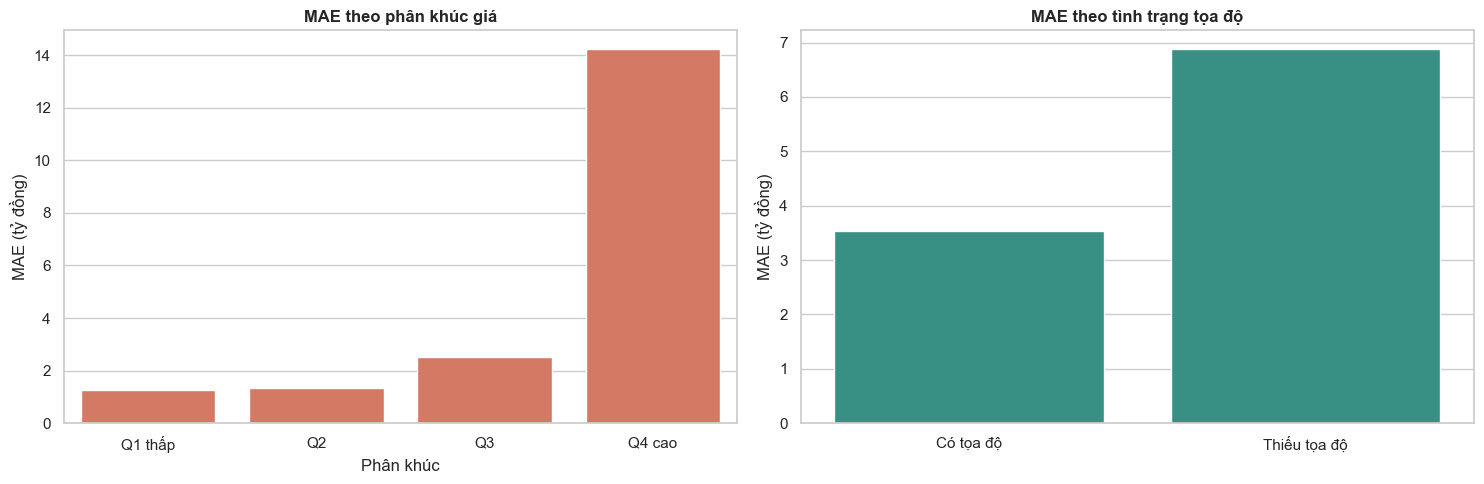

In [17]:
pred_table = test_df[[
    "property_group_id", "listing_id", "ward", "district", "location_regime",
    "coordinate_missing", "area", "price_million",
]].copy()
pred_table["prediction_million"] = best_pred
pred_table["error_million"] = pred_table["prediction_million"] - pred_table["price_million"]
pred_table["absolute_error_million"] = pred_table["error_million"].abs()
pred_table["absolute_percentage_error"] = (
    pred_table["absolute_error_million"] / pred_table["price_million"]
)
pred_table["price_segment"] = pd.qcut(
    pred_table["price_million"],
    q=4,
    labels=["Q1 thấp", "Q2", "Q3", "Q4 cao"],
    duplicates="drop",
)
pred_table["coordinate_status"] = np.where(
    pred_table["coordinate_missing"].eq(1), "Thiếu tọa độ", "Có tọa độ"
)

def summarize_errors(frame, group_col):
    return (
        frame.groupby(group_col, dropna=False, observed=True)
        .agg(
            n=("price_million", "size"),
            mae_billion=("absolute_error_million", lambda s: s.mean() / 1000),
            medae_billion=("absolute_error_million", lambda s: s.median() / 1000),
            mape_pct=("absolute_percentage_error", lambda s: s.mean() * 100),
            mean_signed_error_billion=("error_million", lambda s: s.mean() / 1000),
        )
        .reset_index()
    )

error_by_segment = summarize_errors(pred_table, "price_segment")
error_by_coord = summarize_errors(pred_table, "coordinate_status")
error_by_regime = summarize_errors(pred_table, "location_regime")
error_by_ward = summarize_errors(pred_table, "ward")
error_by_ward = error_by_ward.loc[error_by_ward["n"] >= 15].sort_values(
    "mae_billion", ascending=False
)

display(Markdown("**Sai số theo phân khúc giá**"))
display(error_by_segment.style.format({
    "mae_billion": "{:.3f}", "medae_billion": "{:.3f}",
    "mape_pct": "{:.1f}%", "mean_signed_error_billion": "{:.3f}",
}))
display(Markdown("**Sai số theo tình trạng tọa độ**"))
display(error_by_coord.style.format({
    "mae_billion": "{:.3f}", "medae_billion": "{:.3f}",
    "mape_pct": "{:.1f}%", "mean_signed_error_billion": "{:.3f}",
}))
display(Markdown("**Các phường có MAE cao (n test ≥ 15)**"))
display(error_by_ward.head(15).style.format({
    "mae_billion": "{:.3f}", "medae_billion": "{:.3f}",
    "mape_pct": "{:.1f}%", "mean_signed_error_billion": "{:.3f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=error_by_segment, x="price_segment", y="mae_billion", color="#E76F51", ax=axes[0])
axes[0].set(title="MAE theo phân khúc giá", xlabel="Phân khúc", ylabel="MAE (tỷ đồng)")
sns.barplot(data=error_by_coord, x="coordinate_status", y="mae_billion", color="#2A9D8F", ax=axes[1])
axes[1].set(title="MAE theo tình trạng tọa độ", xlabel="", ylabel="MAE (tỷ đồng)")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "06_error_analysis.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Lưu kết quả và kết luận tự động

Các file CSV giúp nhóm đưa bảng vào báo cáo mà không phải chép tay. Model được lưu bằng `joblib` để có thể nạp lại khi demo.


In [18]:
modeling_export_cols = [
    "property_group_id", "listing_id", "price_million", "area", "width",
    "length", "bedrooms", "bathrooms", "floors", "position", "direction",
    "alley_width", "road_type", "ward", "district", "location_regime",
    "latitude", "longitude", "distance_to_center_km", "coordinate_missing",
    "last_updated_date",
]
modeling[modeling_export_cols].to_csv(
    OUTPUT_DIR / "modeling_data_clean.csv", index=False, encoding="utf-8-sig"
)
quality.to_csv(OUTPUT_DIR / "data_quality.csv", index=False, encoding="utf-8-sig")
cleaning_log.to_csv(OUTPUT_DIR / "cleaning_log.csv", index=False, encoding="utf-8-sig")
cleaning_diagnostics.to_csv(OUTPUT_DIR / "cleaning_diagnostics.csv", index=False, encoding="utf-8-sig")
missingness_before_after.to_csv(OUTPUT_DIR / "coverage_before_after_cleaning.csv", index=False, encoding="utf-8-sig")
coordinate_reuse.to_csv(OUTPUT_DIR / "coordinate_reuse.csv", index=False, encoding="utf-8-sig")
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
ablation.to_csv(OUTPUT_DIR / "location_ablation.csv", index=False, encoding="utf-8-sig")
importance.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False, encoding="utf-8-sig")
pred_table.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")
error_by_segment.to_csv(OUTPUT_DIR / "error_by_price_segment.csv", index=False, encoding="utf-8-sig")
error_by_coord.to_csv(OUTPUT_DIR / "error_by_coordinate_status.csv", index=False, encoding="utf-8-sig")
error_by_regime.to_csv(OUTPUT_DIR / "error_by_location_regime.csv", index=False, encoding="utf-8-sig")
error_by_ward.to_csv(OUTPUT_DIR / "error_by_ward.csv", index=False, encoding="utf-8-sig")
joblib.dump(best_model, MODEL_DIR / "best_house_price_model.joblib")

best_row = comparison.loc[comparison["model"].eq(best_model_name)].iloc[0]
full_ablation = ablation.loc[ablation["feature_set"].eq("Đầy đủ vị trí")].iloc[0]
structure_ablation = ablation.loc[
    ablation["feature_set"].eq("Chỉ đặc điểm căn nhà")
].iloc[0]
location_gain = (
    (structure_ablation["mae_billion"] - full_ablation["mae_billion"])
    / structure_ablation["mae_billion"] * 100
)
top_features = ", ".join(importance.head(5)["feature"].tolist())

conclusion = f'''
## Kết luận từ lần chạy hiện tại

Sau bộ lọc chất lượng và grouping, dữ liệu còn **{len(modeling):,} căn độc lập ước tính**.
Mô hình được chọn bằng cross-validation là **{best_model_name}** với CV MAE trung bình
**{best_row['cv_mae_billion']:.3f} tỷ đồng**. Trên test set, mô hình đạt:

- MAE: **{best_row['mae_billion']:.3f} tỷ đồng**
- RMSE: **{best_row['rmse_billion']:.3f} tỷ đồng**
- MedAE: **{best_row['medae_billion']:.3f} tỷ đồng**
- R²: **{best_row['r2']:.3f}**
- Tỷ lệ dự đoán trong ±20%: **{best_row['within_20pct']:.1f}%**

Khi thêm đầy đủ địa giới thô và tọa độ, MAE thay đổi **{location_gain:.1f}%** so với mô hình
chỉ dùng đặc điểm căn nhà. Năm feature có permutation importance cao nhất là:
**{top_features}**.

### Giới hạn cần nêu trong báo cáo

1. Target là **giá rao**, không phải giá giao dịch thành công.
2. File không chứa `date_posted` thật; `Last Updated Date` và `Scraped At` không thay thế được biến này.
3. Địa giới cũ/mới bị trộn. Tọa độ chỉ tập trung ở nhóm ghi địa giới mới, nên thiếu tọa độ không ngẫu nhiên.
4. Grouping dựa trên heuristic; vẫn có thể còn hai tin của cùng một căn hoặc gộp nhầm một số căn giống nhau.
5. Dữ liệu là lát cắt ngắn quanh tháng 9/2025, nên chưa đủ để kết luận về biến động giá theo thời gian.
6. Permutation importance mô tả giá trị dự báo, không phải tác động nhân quả.

Kết quả có thể dùng để **so sánh mô hình trong phạm vi dataset**, không nên trình bày như công cụ định giá
chính thức cho toàn bộ thị trường TP.HCM.
'''
display(Markdown(conclusion))
print("Đã lưu kết quả tại:", OUTPUT_DIR)
print("Đã lưu mô hình tại:", MODEL_DIR / "best_house_price_model.joblib")



## Kết luận từ lần chạy hiện tại

Sau bộ lọc chất lượng và grouping, dữ liệu còn **7,482 căn độc lập ước tính**.
Mô hình được chọn bằng cross-validation là **Gradient Boosting** với CV MAE trung bình
**4.801 tỷ đồng**. Trên test set, mô hình đạt:

- MAE: **4.831 tỷ đồng**
- RMSE: **15.878 tỷ đồng**
- MedAE: **1.536 tỷ đồng**
- R²: **0.629**
- Tỷ lệ dự đoán trong ±20%: **50.6%**

Khi thêm đầy đủ địa giới thô và tọa độ, MAE thay đổi **31.1%** so với mô hình
chỉ dùng đặc điểm căn nhà. Năm feature có permutation importance cao nhất là:
**area, ward, district, distance_to_center_km, floors**.

### Giới hạn cần nêu trong báo cáo

1. Target là **giá rao**, không phải giá giao dịch thành công.
2. File không chứa `date_posted` thật; `Last Updated Date` và `Scraped At` không thay thế được biến này.
3. Địa giới cũ/mới bị trộn. Tọa độ chỉ tập trung ở nhóm ghi địa giới mới, nên thiếu tọa độ không ngẫu nhiên.
4. Grouping dựa trên heuristic; vẫn có thể còn hai tin của cùng một căn hoặc gộp nhầm một số căn giống nhau.
5. Dữ liệu là lát cắt ngắn quanh tháng 9/2025, nên chưa đủ để kết luận về biến động giá theo thời gian.
6. Permutation importance mô tả giá trị dự báo, không phải tác động nhân quả.

Kết quả có thể dùng để **so sánh mô hình trong phạm vi dataset**, không nên trình bày như công cụ định giá
chính thức cho toàn bộ thị trường TP.HCM.


Đã lưu kết quả tại: D:\bài làm nháp đồ án KHDL\outputs_notebook
Đã lưu mô hình tại: D:\bài làm nháp đồ án KHDL\models\best_house_price_model.joblib


## Gợi ý cấu trúc báo cáo đồ án

1. **Giới thiệu:** bối cảnh, mục tiêu, câu hỏi nghiên cứu và phạm vi “giá rao nhà riêng”.
2. **Dữ liệu:** nguồn, thời điểm thu thập, đơn vị quan sát, schema, coverage và các vấn đề địa giới.
3. **Phương pháp:** quy tắc làm sạch, grouping repost, feature engineering, split chống leakage, mô hình và metric.
4. **Kết quả:** bảng cross-validation, test set, ablation vị trí và permutation importance.
5. **Error analysis:** phân khúc giá, tọa độ, địa giới và các phường có sai số cao.
6. **Thảo luận:** ý nghĩa kết quả, độ tin cậy, hạn chế và hướng phát triển.
7. **Kết luận:** trả lời lần lượt RQ1-RQ4, không diễn giải tương quan như quan hệ nhân quả.

Trước khi nộp, nhóm cần bổ sung **citation/source, license/quyền sử dụng, cách thu thập và ý nghĩa chính xác của `Price`** từ nơi cung cấp dataset.
